In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import rasterio
from rasterio import plot
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import math
from sklearn.metrics import f1_score, precision_score, recall_score
from scipy.interpolate import griddata
import joblib
from tqdm import tqdm
import seaborn as sns
import numpy as np
import geopandas as gpd
from shapely.geometry import box
from dataclasses import dataclass
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pyproj import Transformer

sns.set_theme()

In [3]:
from utils.site import Site
from utils.tree import Tree
from utils.constants import (
    GH_ASHANTI_GDF,
    ETHZ_COCOA_MAP_THRESHOLDED_FILEPATH,
    ETHZ_COCOA_MAP_FILEPATH,
    SILVER_FOLDERPATH,
    ETHZ_COCOA_MAP_UINT8_FILEPATH,
    SENTINEL_SCENES_FOLDERPATH,
)

In [11]:
# Load sites
sites = joblib.load(SILVER_FOLDERPATH / "sites.pkl")
print(f"Loaded {len(sites)} sites")

Loaded 155 sites


In [7]:
# Generate random points across Ghana
N_POINTS = 10_000

ghana_metric = GH_ASHANTI_GDF.to_crs(epsg=32630)

# Get ghana boundary
ghana_poly = ghana_metric.union_all()
min_x, min_y, max_x, max_y = ghana_poly.bounds

random_points = []

# Vectorized rejection sampling loop for speed
while len(random_points) < N_POINTS:
    # Generate a buffer batch of points to minimize looping overhead
    batch_size = (N_POINTS - len(random_points)) * 2

    xs = np.random.uniform(min_x, max_x, batch_size)
    ys = np.random.uniform(min_y, max_y, batch_size)

    # Create shapely Point objects
    possible_points = [Point(x, y) for x, y in zip(xs, ys)]

    # Keep only points that fall inside the actual shape of Ghana
    valid_points = [p for p in possible_points if ghana_poly.contains(p)]

    random_points.extend(valid_points)

# Trim down to exactly 10,000 in case the last batch overshot
random_points = random_points[:N_POINTS]

# Create a new GeoDataFrame and project back to WGS84 (Lat/Lon)
random_points_gdf = gpd.GeoDataFrame(geometry=random_points, crs=ghana_metric.crs)
random_points_gdf = random_points_gdf.to_crs(epsg=4326)
random_points_gdf["lon"] = random_points_gdf.geometry.x
random_points_gdf["lat"] = random_points_gdf.geometry.y
random_points_gdf["lonlat"] = random_points_gdf.apply(lambda row: (row["lon"], row["lat"]), axis=1)

print(f"Generated {len(random_points_gdf)} valid random points inside Ghana.")

Generated 10000 valid random points inside Ghana.


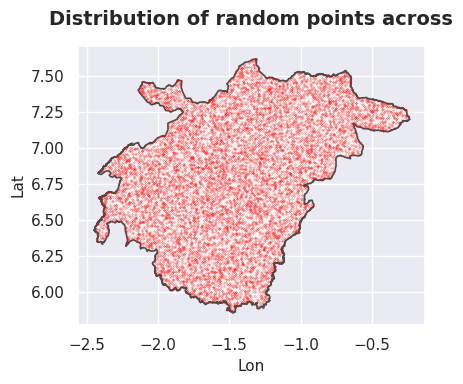

In [8]:
# Plot our random samples
def plot_map(gdf: gpd.GeoDataFrame, point_gdf: gpd.GeoDataFrame) -> None:
    fig, ax = plt.subplots(figsize=(6, 4))
    
    gdf.plot(ax=ax, color="#f0f0f0", edgecolor="#4d4d4d", linewidth=1.2)
    point_gdf.plot(ax=ax, color="RED", markersize=0.05, alpha=0.8)
    
    ax.set_title("Distribution of random points across", fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Lon", fontsize=11)
    ax.set_ylabel("Lat", fontsize=11)
    
    plt.tight_layout()
    plt.show()

plot_map(GH_ASHANTI_GDF, random_points_gdf)